### Modelos usados retornos
1. Petroleo (2,0,0), seasonal_order=(2,1,0,100)
2. Microsoft order=(3,0,3), seasonal_order=(1,1,1,100)
3. Nvidia (1,0,2),seasonal_order=(1,1,2,80)

## Aplicación de cópulas al modelo residual (petroleo y microsoft)

### Bases de datos

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import drive
import os
import scipy.stats as stats
import numpy as np


In [ ]:
found_path = None
for root, dirs, files in os.walk('/content/drive/MyDrive/'):
    if 'residuos_petroleo(r).csv' in files:
        found_path = os.path.join(root, 'residuos_petroleo(r).csv')
        print(f"Encontrado: {found_path}")
        break
for root, dirs, files in os.walk('/content/drive/MyDrive/'):
    if 'residuos_microsoft(r).csv' in files:
        found_path = os.path.join(root, 'residuos_microsoft(r).csv')
        print(f"Encontado: {found_path}")
        break
for root, dirs, files in os.walk('/content/drive/MyDrive/'):
    if 'residuos_nvidia(r).csv' in files:
        found_path = os.path.join(root, 'residuos_nvidia(r).csv')
        print(f"Encontrado: {found_path}")
        break

Encontrado: /content/drive/MyDrive/Tesis Julio Dolores/Parámetros (Modelo SARIMA)/residuos_petroleo(r).csv
Encontado: /content/drive/MyDrive/Tesis Julio Dolores/Parámetros (Modelo SARIMA)/residuos_microsoft(r).csv
Encontrado: /content/drive/MyDrive/Tesis Julio Dolores/Parámetros (Modelo SARIMA)/residuos_nvidia(r).csv


In [ ]:
if 'base_path' not in locals():
    base_path = '/content/drive/MyDrive/Tesis Julio Dolores/Parametros (Modelo SARIMA)'

file_name = 'parametros_microsoft.csv'
file_path = os.path.join(base_path, file_name)

try:
    df_parametros_microsoft = pd.read_csv(file_path)
    print(f"Successfully loaded {file_name}:")
    display(df_parametros_microsoft.head())
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found at '{file_path}'. Please check the filename and path.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

file_name_petroleo = 'parametros_petroleo.csv'
file_path_petroleo = os.path.join(base_path, file_name_petroleo)

try:
    df_parametros_petroleo = pd.read_csv(file_path_petroleo)
    print(f"Successfully loaded {file_name_petroleo}:")
    display(df_parametros_petroleo.head())
except FileNotFoundError:
    print(f"Error: The file '{file_name_petroleo}' was not found at '{file_path_petroleo}'. Please check the filename and path.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

file_name_nvidia = 'parametros_nvidia.csv'
file_path_nvidia = os.path.join(base_path, file_name_nvidia)

try:
    df_parametros_nvidia = pd.read_csv(file_path_nvidia)
    print(f"Successfully loaded {file_name_nvidia}:")
    display(df_parametros_nvidia.head())
except FileNotFoundError:
    print(f"Error: The file '{file_name_nvidia}' was not found at '{file_path_nvidia}'. Please check the filename and path.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Successfully loaded parametros_microsoft.csv:


,parametro,valor,error_std,p_valor
0,ar.L1,-0.531717,0.338833,0.116588
1,ar.L2,-0.265132,0.330175,0.421972
2,ar.L3,-0.375010,0.333442,0.260731
3,ma.L1,0.521916,0.347550,0.133175
4,ma.L2,0.211828,0.343432,0.537369


Successfully loaded parametros_petroleo.csv:


,parametro,valor,error_std,p_valor
0,ar.L1,0.028522,0.032266,3.767248e-01
1,ar.L2,-0.053912,0.026898,4.503588e-02
2,ar.S.L100,-0.644325,0.028811,8.913103e-111
3,ar.S.L200,-0.312178,0.031304,2.010554e-23
4,sigma2,0.000699,0.000024,1.380068e-188


Successfully loaded parametros_nvidia.csv:


,parametro,valor,error_std,p_valor
0,ar.L1,0.511757,2.353651,0.827872
1,ma.L1,-0.542250,2.353254,0.817761
2,ma.L2,0.007186,0.091535,0.937429
3,ar.S.L80,-0.836270,0.373898,0.025311
4,ma.S.L80,-0.170307,0.433834,0.694643


In [ ]:
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Tesis Julio Dolores/Parámetros (Modelo SARIMA)'

#Bases de datos
resid_pet = pd.read_csv(os.path.join(base_path, 'residuos_petroleo(r).csv'))
resid_micr = pd.read_csv(os.path.join(base_path, 'residuos_microsoft(r).csv'))
resid_nvd = pd.read_csv(os.path.join(base_path, 'residuos_nvidia(r).csv'))

# Renombrar la primera columna (se llama 0)
resid_pet.rename(columns={resid_pet.columns[0]: 'residuos_p'}, inplace=True)
resid_micr.rename(columns={resid_micr.columns[0]: 'residuos_m'}, inplace=True)
resid_nvd.rename(columns={resid_nvd.columns[0]: 'residuos_n'}, inplace=True)

#DataFrame combinado
residuos_df = pd.DataFrame({
    'residuos_petroleo': resid_pet['residuos_p'],
    'residuos_microsoft': resid_micr['residuos_m'],
    'residuos_nvidia': resid_nvd['residuos_n']
})

for col in residuos_df.columns: #estandarizar los residuos
    residuos_df[col] = stats.zscore(residuos_df[col], nan_policy='omit')
print("Valores nulos por columna:")
print(residuos_df.isnull().sum())
residuos_df = residuos_df.dropna()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Valores nulos por columna:
residuos_petroleo     0
residuos_microsoft    3
residuos_nvidia       3
dtype: int64


In [ ]:
base_path2 = '/content/drive/MyDrive/Tesis Julio Dolores/Bases de datos'

#Bases de datos
entr_pet = pd.read_csv(os.path.join(base_path2, 'entrenamiento_petroleo.csv'))
entr_micr = pd.read_csv(os.path.join(base_path2, 'entrenamiento_microsoft.csv'))
entr_nvd = pd.read_csv(os.path.join(base_path2, 'entrenamiento_nvidia.csv'))


In [ ]:
entr_micr = entr_micr.set_index('Date')
entr_pet = entr_pet.set_index('Date')
entr_nvd = entr_nvd.set_index('Date')

In [ ]:
entr_pet=np.log(entr_pet['Close']/entr_pet['Close'].shift(1).dropna())
entr_micr=np.log(entr_micr['Close']/entr_micr['Close'].shift(1).dropna())
entr_nvd=np.log(entr_nvd['Close']/entr_nvd['Close'].shift(1).dropna())

### Scatterplot de los residuos

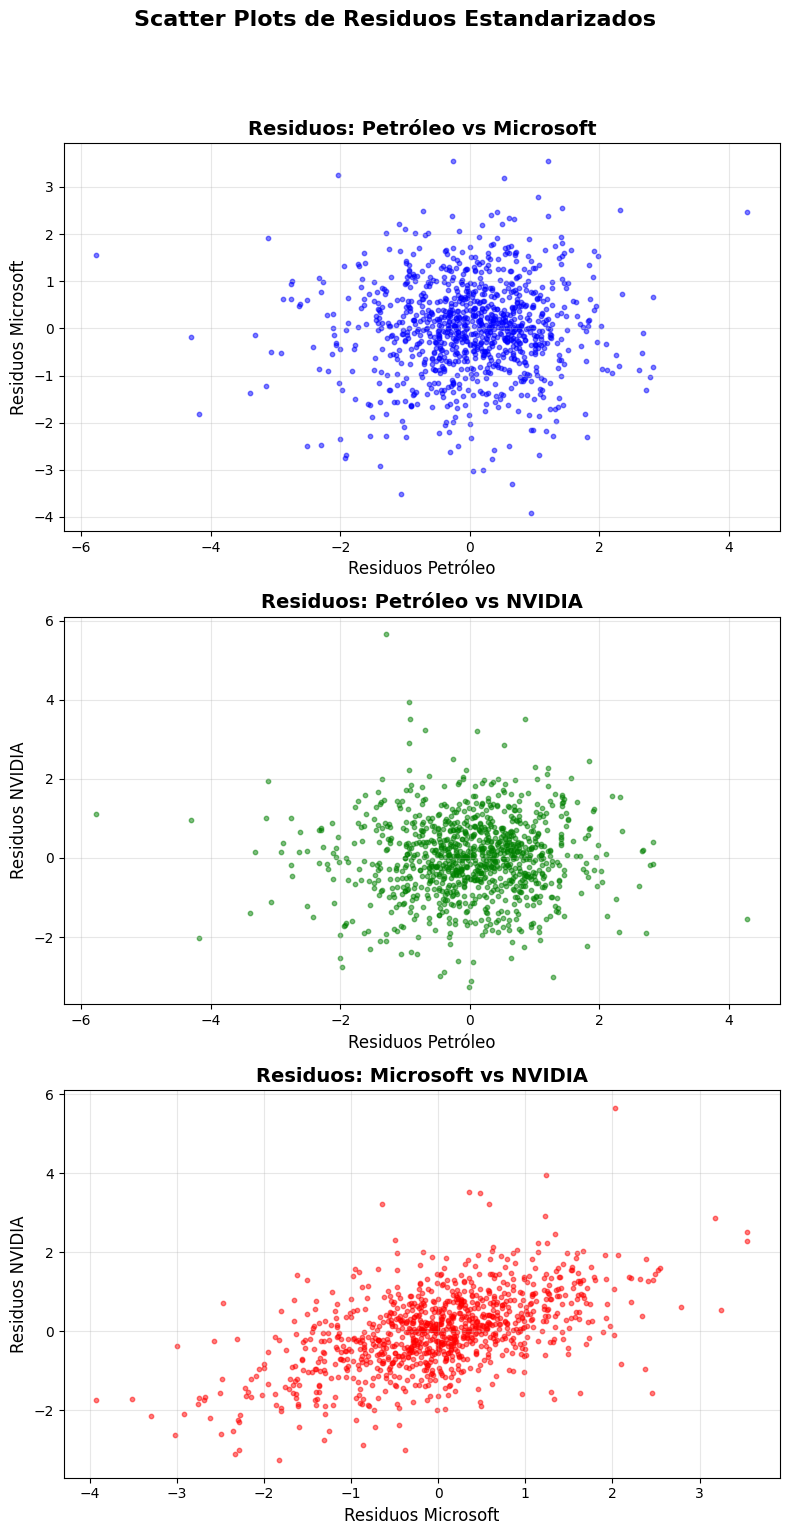

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15))

# 1. Petróleo vs Microsoft
axes[0].scatter(residuos_df['residuos_petroleo'],
                   residuos_df['residuos_microsoft'],
                   alpha=0.5, c='blue', s=10)
axes[0].set_xlabel('Residuos Petróleo', fontsize=12)
axes[0].set_ylabel('Residuos Microsoft', fontsize=12)
axes[0].set_title('Residuos: Petróleo vs Microsoft', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 2. Petróleo vs NVIDIA
axes[1].scatter(residuos_df['residuos_petroleo'],
                   residuos_df['residuos_nvidia'],
                   alpha=0.5, c='green', s=10)
axes[1].set_xlabel('Residuos Petróleo', fontsize=12)
axes[1].set_ylabel('Residuos NVIDIA', fontsize=12)
axes[1].set_title('Residuos: Petróleo vs NVIDIA', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 3. Microsoft vs NVIDIA
axes[2].scatter(residuos_df['residuos_microsoft'],
                   residuos_df['residuos_nvidia'],
                   alpha=0.5, c='red', s=10)
axes[2].set_xlabel('Residuos Microsoft', fontsize=12)
axes[2].set_ylabel('Residuos NVIDIA', fontsize=12)
axes[2].set_title('Residuos: Microsoft vs NVIDIA', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Scatter Plots de Residuos Estandarizados', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Correlaciones de las series

In [ ]:
# Spearman y Kendall
# Petróleo vs Microsoft
spearman_p_m = stats.spearmanr(residuos_df['residuos_petroleo'], residuos_df['residuos_microsoft']).correlation
kendall_p_m = stats.kendalltau(residuos_df['residuos_petroleo'], residuos_df['residuos_microsoft']).correlation

# Petróleo vs NVIDIA
spearman_p_n = stats.spearmanr(residuos_df['residuos_petroleo'], residuos_df['residuos_nvidia']).correlation
kendall_p_n = stats.kendalltau(residuos_df['residuos_petroleo'], residuos_df['residuos_nvidia']).correlation

# Microsoft vs NVIDIA
spearman_m_n = stats.spearmanr(residuos_df['residuos_microsoft'], residuos_df['residuos_nvidia']).correlation
kendall_m_n = stats.kendalltau(residuos_df['residuos_microsoft'], residuos_df['residuos_nvidia']).correlation

print(f"CORRELACIONES:")
print(f"Petróleo vs Microsoft:")
print(f"  Spearman: {spearman_p_m:.4f}")
print(f"  Kendall:  {kendall_p_m:.4f}")
print()
print(f"Petróleo vs NVIDIA:")
print(f"  Spearman: {spearman_p_n:.4f}")
print(f"  Kendall:  {kendall_p_n:.4f}")
print()
print(f"Microsoft vs NVIDIA:")
print(f"  Spearman: {spearman_m_n:.4f}")
print(f"  Kendall:  {kendall_m_n:.4f}")


CORRELACIONES:
Petróleo vs Microsoft:
  Spearman: 0.0170
  Kendall:  0.0108

Petróleo vs NVIDIA:
  Spearman: 0.0374
  Kendall:  0.0253

Microsoft vs NVIDIA:
  Spearman: 0.5203
  Kendall:  0.3693


### cópula empírica

In [ ]:
def copula_empirica(u, v):
    """
    Calcula la cópula empírica bivariada usando el enfoque de rango
    C_n(u,v) = (1/(n+1)) * Σ I(U_i ≤ u, V_i ≤ v)
    """
    n = len(u)
    C_emp = np.zeros(n)

    for i in range(n):
        C_emp[i] = np.sum((u <= u[i]) & (v <= v[i])) / (n + 1)

    return C_emp

def transformar_a_copula_empirica(returns_series1, returns_series2):
    """
    Transforma los rendimientos a cópula empírica usando rangos
    """
    data = pd.DataFrame({
        'x': returns_series1.dropna(),
        'y': returns_series2.dropna()
    }).dropna()

    n = len(data)
    data['rank_x'] = data['x'].rank() / (n + 1)
    data['rank_y'] = data['y'].rank() / (n + 1)

    return data['rank_x'].values, data['rank_y'].values


### Transformación de las series a cópulas empíricas

In [ ]:
u_pet_mic, v_mic_pet = transformar_a_copula_empirica(residuos_df['residuos_petroleo'], residuos_df['residuos_microsoft'])
u_pet_nvd, v_nvd_pet = transformar_a_copula_empirica(residuos_df['residuos_petroleo'], residuos_df['residuos_nvidia'])
u_mic_nvd, v_nvd_mic = transformar_a_copula_empirica(residuos_df['residuos_microsoft'], residuos_df['residuos_nvidia'])

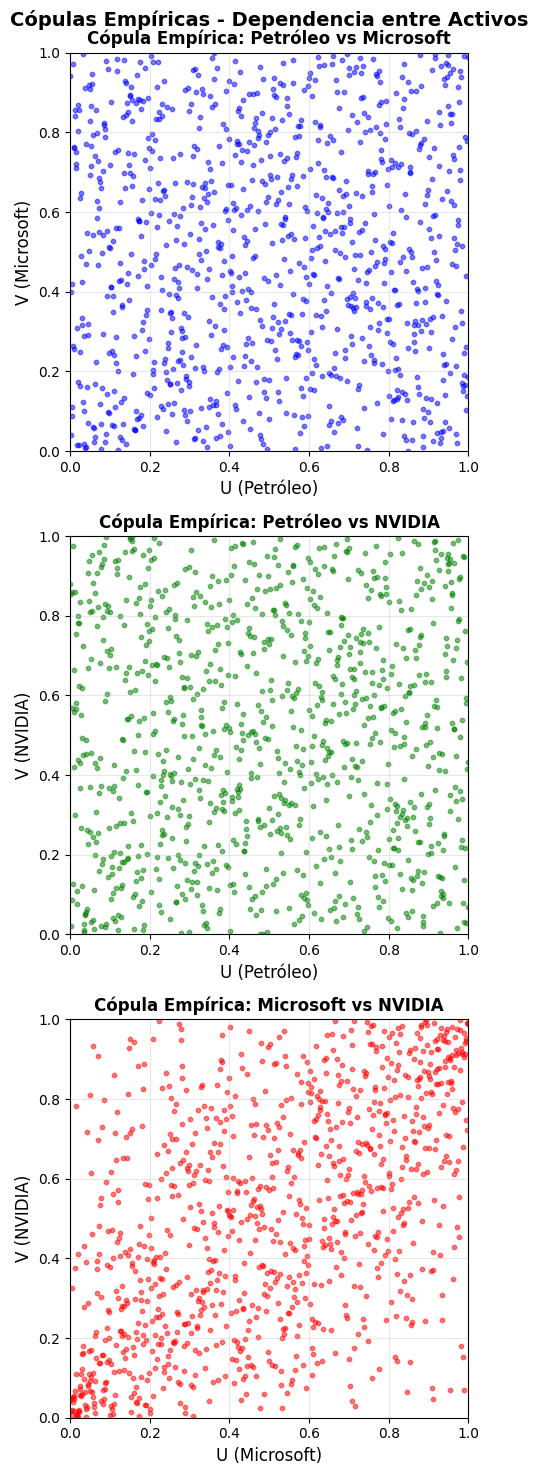

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15))  # Cambiado a 3 filas, 1 columna

# Cópula Petróleo-Microsoft
axes[0].scatter(u_pet_mic, v_mic_pet, alpha=0.5, c='blue', s=10)
axes[0].set_xlabel('U (Petróleo)', fontsize=12)
axes[0].set_ylabel('V (Microsoft)', fontsize=12)
axes[0].set_title('Cópula Empírica: Petróleo vs Microsoft', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_aspect('equal')

# Cópula Petróleo-NVIDIA
axes[1].scatter(u_pet_nvd, v_nvd_pet, alpha=0.5, c='green', s=10)
axes[1].set_xlabel('U (Petróleo)', fontsize=12)
axes[1].set_ylabel('V (NVIDIA)', fontsize=12)
axes[1].set_title('Cópula Empírica: Petróleo vs NVIDIA', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_aspect('equal')

# Cópula Microsoft-NVIDIA
axes[2].scatter(u_mic_nvd, v_nvd_mic, alpha=0.5, c='red', s=10)
axes[2].set_xlabel('U (Microsoft)', fontsize=12)
axes[2].set_ylabel('V (NVIDIA)', fontsize=12)
axes[2].set_title('Cópula Empírica: Microsoft vs NVIDIA', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].set_aspect('equal')

plt.suptitle('Cópulas Empíricas - Dependencia entre Activos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Encontrar los parámetros para cada cópula

In [ ]:
import sympy as sp
import numpy as np
from scipy.optimize import minimize
from scipy import stats
import pandas as pd

def estimar_parametros_copula(u, v):
    u_sym, v_sym, theta_sym = sp.symbols('u v theta', real=True)

    resultados = []

    # Copula de Clayton
    C_clayton = (u_sym**(-theta_sym) + v_sym**(-theta_sym) - 1)**(-1/theta_sym)
    densidad_clayton = sp.diff(sp.diff(C_clayton, u_sym), v_sym)
    densidad_clayton_simp = sp.simplify(densidad_clayton)
    densidad_clayton_func = sp.lambdify((u_sym, v_sym, theta_sym), densidad_clayton_simp, 'numpy')
    C_clayton_func = sp.lambdify((u_sym, v_sym, theta_sym), C_clayton, 'numpy')

    # Copula de Gumbel
    a = (-sp.log(u_sym))**theta_sym
    b = (-sp.log(v_sym))**theta_sym
    C_gumbel = sp.exp(-(a + b)**(1/theta_sym))
    densidad_gumbel = sp.diff(sp.diff(C_gumbel, u_sym), v_sym)
    densidad_gumbel_simp = sp.simplify(densidad_gumbel)
    densidad_gumbel_func = sp.lambdify((u_sym, v_sym, theta_sym), densidad_gumbel_simp, 'numpy')
    C_gumbel_func = sp.lambdify((u_sym, v_sym, theta_sym), C_gumbel, 'numpy')

    # Copula de Frank
    C_frank = -1/theta_sym * sp.log(1 + ((sp.exp(-theta_sym * u_sym) - 1) * (sp.exp(-theta_sym * v_sym) - 1)) / (sp.exp(-theta_sym) - 1))
    densidad_frank = sp.diff(sp.diff(C_frank, u_sym), v_sym)
    densidad_frank_simp = sp.simplify(densidad_frank)
    densidad_frank_func = sp.lambdify((u_sym, v_sym, theta_sym), densidad_frank_simp, 'numpy')
    C_frank_func = sp.lambdify((u_sym, v_sym, theta_sym), C_frank, 'numpy')

    # Funciones de verosimilitud para las cópulas existentes
    def verosimilitud_clayton(theta):
        if theta <= 0:
            return 1e10
        log_lik = 0
        for i in range(len(u)):
            try:
                dens = densidad_clayton_func(u[i], v[i], theta)
                if dens > 0:
                    log_lik += np.log(dens)
            except:
                continue
        return -log_lik if not np.isnan(-log_lik) and not np.isinf(-log_lik) else 1e10

    def verosimilitud_gumbel(theta):
        if theta < 1:
            return 1e10
        log_lik = 0
        for i in range(len(u)):
            try:
                dens = densidad_gumbel_func(u[i], v[i], theta)
                if dens > 0 and not np.isnan(dens):
                    log_lik += np.log(dens)
            except:
                continue
        return -log_lik if not np.isnan(-log_lik) and not np.isinf(-log_lik) else 1e10

    def verosimilitud_frank(theta):
        if theta == 0:
            return 1e10
        log_lik = 0
        for i in range(len(u)):
            try:
                dens = densidad_frank_func(u[i], v[i], theta)
                if dens > 0 and not np.isnan(dens) and not np.isinf(dens):
                    log_lik += np.log(dens)
            except:
                continue
        return -log_lik if not np.isnan(-log_lik) and not np.isinf(-log_lik) else 1e10

    # Cópula Gaussiana
    def densidad_gaussiana(u, v, rho):
        """Densidad de la cópula Gaussiana"""
        if abs(rho) >= 1:
            return 0
        try:
            x = stats.norm.ppf(u)
            y = stats.norm.ppf(v)
            dens = (1/np.sqrt(1-rho**2)) * np.exp(-(rho**2*(x**2+y**2) - 2*rho*x*y)/(2*(1-rho**2)))
            return dens
        except:
            return 0

    def C_gaussiana(u, v, rho):
        """Función de distribución de la cópula Gaussiana"""
        if abs(rho) >= 1:
            return 0
        try:
            x = stats.norm.ppf(u)
            y = stats.norm.ppf(v)
            return stats.multivariate_normal.cdf([x, y], mean=[0, 0], cov=[[1, rho], [rho, 1]])
        except:
            return 0

    def verosimilitud_gaussiana(params):
        rho = params[0]
        if abs(rho) >= 0.999:  # Evitar correlación perfecta
            return 1e10
        log_lik = 0
        for i in range(len(u)):
            try:
                dens = densidad_gaussiana(u[i], v[i], rho)
                if dens > 0 and not np.isnan(dens) and not np.isinf(dens):
                    log_lik += np.log(dens)
            except:
                continue
        return -log_lik if not np.isnan(-log_lik) and not np.isinf(-log_lik) else 1e10

    # Cópula t-Student
    def densidad_t_student(u, v, rho, nu):
        """Densidad de la cópula t-Student"""
        if abs(rho) >= 1 or nu <= 2:
            return 0
        try:
            x = stats.t.ppf(u, nu)
            y = stats.t.ppf(v, nu)

            # Densidad de la t-Student bivariada
            dens_multivariate = (1/(2*np.pi*np.sqrt(1-rho**2))) * \
                (1 + (x**2 + y**2 - 2*rho*x*y)/(nu*(1-rho**2)))**(-(nu+2)/2)

            # Densidades marginales
            dens_marginal_x = stats.t.pdf(x, nu)
            dens_marginal_y = stats.t.pdf(y, nu)

            # Densidad de la cópula
            dens = dens_multivariate / (dens_marginal_x * dens_marginal_y)
            return dens
        except:
            return 0

    def C_t_student(u, v, rho, nu):
        """Función de distribución de la cópula t-Student"""
        if abs(rho) >= 1 or nu <= 2:
            return 0
        try:
            x = stats.t.ppf(u, nu)
            y = stats.t.ppf(v, nu)

            # Usar la CDF de la t-Student bivariada
            from scipy.stats import multivariate_t
            cov = [[1, rho], [rho, 1]]
            return multivariate_t.cdf([x, y], shape=cov, df=nu)
        except:
            return 0

    def verosimilitud_t_student(params):
        rho = params[0]
        nu = params[1]
        if abs(rho) >= 0.999 or nu <= 2.001:  # nu debe ser > 2
            return 1e10
        log_lik = 0
        for i in range(len(u)):
            try:
                dens = densidad_t_student(u[i], v[i], rho, nu)
                if dens > 0 and not np.isnan(dens) and not np.isinf(dens):
                    log_lik += np.log(dens)
            except:
                continue
        return -log_lik if not np.isnan(-log_lik) and not np.isinf(-log_lik) else 1e10

    # Optimización para las cópulas arquimedianas
    try:
        resultado_clayton = minimize(verosimilitud_clayton, [1.0], method='L-BFGS-B', bounds=[(0.001, 20)])
        param_clayton = resultado_clayton.x[0]
        loglik_clayton = -resultado_clayton.fun
    except:
        param_clayton = np.nan
        loglik_clayton = -np.inf

    try:
        resultado_gumbel = minimize(verosimilitud_gumbel, [2.0], method='L-BFGS-B', bounds=[(1.001, 20)])
        param_gumbel = resultado_gumbel.x[0]
        loglik_gumbel = -resultado_gumbel.fun
    except:
        param_gumbel = np.nan
        loglik_gumbel = -np.inf

    try:
        resultado_frank1 = minimize(verosimilitud_frank, [2.0], method='L-BFGS-B', bounds=[(0.001, 20)])
        resultado_frank2 = minimize(verosimilitud_frank, [-2.0], method='L-BFGS-B', bounds=[(-20, -0.001)])

        if resultado_frank1.fun < resultado_frank2.fun:
            param_frank = resultado_frank1.x[0]
            loglik_frank = -resultado_frank1.fun
        else:
            param_frank = resultado_frank2.x[0]
            loglik_frank = -resultado_frank2.fun
    except:
        param_frank = np.nan
        loglik_frank = -np.inf

    # Optimización para la cópula Gaussiana
    try:
        resultado_gaussiana = minimize(verosimilitud_gaussiana, [0.5], method='L-BFGS-B', bounds=[(-0.999, 0.999)])
        param_gaussiana = resultado_gaussiana.x[0]
        loglik_gaussiana = -resultado_gaussiana.fun
    except:
        param_gaussiana = np.nan
        loglik_gaussiana = -np.inf

    # Optimización para la cópula t-Student
    try:
        resultado_t_student = minimize(verosimilitud_t_student, [0.5, 5], method='L-BFGS-B',
                                      bounds=[(-0.999, 0.999), (2.001, 30)])
        param_t_rho = resultado_t_student.x[0]
        param_t_nu = resultado_t_student.x[1]
        loglik_t_student = -resultado_t_student.fun
    except:
        param_t_rho = np.nan
        param_t_nu = np.nan
        loglik_t_student = -np.inf

    # Pruebas de bondad de ajuste
    def prueba_ad_copula(u, v, copula_func, *args):
        n = len(u)
        C_emp = copula_empirica(u, v)
        try:
            C_teo = np.array([copula_func(u[i], v[i], *args) for i in range(n)])
            indices_ordenados = np.argsort(C_teo)
            C_teo_sorted = C_teo[indices_ordenados]
            C_emp_sorted = C_emp[indices_ordenados]

            i = np.arange(1, n + 1)
            ad_stat = -n - np.sum((2*i - 1) * (np.log(C_teo_sorted) + np.log(1 - C_emp_sorted[::-1]))) / n
            return ad_stat
        except:
            return np.inf

    def prueba_iad_copula(u, v, copula_func, *args):
        n = len(u)
        C_emp = copula_empirica(u, v)
        try:
            C_teo = np.array([copula_func(u[i], v[i], *args) for i in range(n)])
            iad_stat = np.sum((C_teo - C_emp)**2)
            return iad_stat
        except:
            return np.inf

    # Calcular estadísticos de bondad de ajuste
    if not np.isnan(param_clayton):
        ad_clayton = prueba_ad_copula(u, v, C_clayton_func, param_clayton)
        iad_clayton = prueba_iad_copula(u, v, C_clayton_func, param_clayton)
    else:
        ad_clayton, iad_clayton = np.inf, np.inf

    if not np.isnan(param_gumbel):
        ad_gumbel = prueba_ad_copula(u, v, C_gumbel_func, param_gumbel)
        iad_gumbel = prueba_iad_copula(u, v, C_gumbel_func, param_gumbel)
    else:
        ad_gumbel, iad_gumbel = np.inf, np.inf

    if not np.isnan(param_frank):
        ad_frank = prueba_ad_copula(u, v, C_frank_func, param_frank)
        iad_frank = prueba_iad_copula(u, v, C_frank_func, param_frank)
    else:
        ad_frank, iad_frank = np.inf, np.inf

    if not np.isnan(param_gaussiana):
        ad_gaussiana = prueba_ad_copula(u, v, C_gaussiana, param_gaussiana)
        iad_gaussiana = prueba_iad_copula(u, v, C_gaussiana, param_gaussiana)
    else:
        ad_gaussiana, iad_gaussiana = np.inf, np.inf

    if not np.isnan(param_t_rho) and not np.isnan(param_t_nu):
        ad_t_student = prueba_ad_copula(u, v, C_t_student, param_t_rho, param_t_nu)
        iad_t_student = prueba_iad_copula(u, v, C_t_student, param_t_rho, param_t_nu)
    else:
        ad_t_student, iad_t_student = np.inf, np.inf

    #tabla
    resultados = [
        {'Cópula': 'Clayton', 'Parámetro 1': param_clayton, 'Parámetro 2': np.nan,
         'Log-Lik': loglik_clayton, 'AD': ad_clayton, 'IAD': iad_clayton},
        {'Cópula': 'Gumbel', 'Parámetro 1': param_gumbel, 'Parámetro 2': np.nan,
         'Log-Lik': loglik_gumbel, 'AD': ad_gumbel, 'IAD': iad_gumbel},
        {'Cópula': 'Frank', 'Parámetro 1': param_frank, 'Parámetro 2': np.nan,
         'Log-Lik': loglik_frank, 'AD': ad_frank, 'IAD': iad_frank},
        {'Cópula': 'Gaussiana', 'Parámetro 1': param_gaussiana, 'Parámetro 2': np.nan,
         'Log-Lik': loglik_gaussiana, 'AD': ad_gaussiana, 'IAD': iad_gaussiana},
        {'Cópula': 't-Student', 'Parámetro 1': param_t_rho, 'Parámetro 2': param_t_nu,
         'Log-Lik': loglik_t_student, 'AD': ad_t_student, 'IAD': iad_t_student}
    ]

    tabla = pd.DataFrame(resultados)
    tabla = tabla.sort_values('Log-Lik', ascending=False)

    return tabla, densidad_clayton_simp, densidad_gumbel_simp, densidad_frank_simp

def copula_empirica(u, v):
    """Función auxiliar para calcular la cópula empírica"""
    n = len(u)
    C_emp = np.zeros(n)
    for i in range(n):
        C_emp[i] = np.sum((u <= u[i]) & (v <= v[i])) / n
    return C_emp

In [ ]:
tabla_resultados1, dens_clayton1, dens_gumbel1, dens_frank1= estimar_parametros_copula(u_pet_mic, v_mic_pet)
print('Resultados Pet-Micro')
tabla_resultados1

Resultados Pet-Micro


,Cópula,Parámetro 1,Parámetro 2,Log-Lik,AD,IAD
4,t-Student,0.025084,7.60745,6.683606,391.106374,0.021210
1,Gumbel,1.029401,NaN,2.015307,383.911749,0.036690
0,Clayton,0.058976,NaN,1.585622,380.942970,0.029239
3,Gaussiana,0.032963,NaN,0.532208,387.663167,0.030190
2,Frank,0.107120,NaN,0.151541,393.740897,0.028506


In [ ]:
tabla_resultados2, dens_clayton2, dens_gumbel2, dens_frank2= estimar_parametros_copula(u_pet_nvd, v_nvd_pet)
print('Resultados Pet-NVIDIA')
tabla_resultados2

Resultados Pet-NVIDIA


,Cópula,Parámetro 1,Parámetro 2,Log-Lik,AD,IAD
4,t-Student,0.042345,9.273561,4.549394,381.557375,0.018134
0,Clayton,0.066207,NaN,1.887410,376.366693,0.019450
1,Gumbel,1.026243,NaN,1.008490,383.704686,0.026884
2,Frank,0.235887,NaN,0.736233,382.312653,0.024354
3,Gaussiana,0.036875,NaN,0.666128,383.974321,0.025157


In [ ]:
tabla_resultados3, dens_clayton3, dens_gumbel3, dens_frank3= estimar_parametros_copula(u_mic_nvd, v_nvd_mic)
print('Resultados NVIDIA-Micro')
tabla_resultados3

Resultados NVIDIA-Micro


,Cópula,Parámetro 1,Parámetro 2,Log-Lik,AD,IAD
4,t-Student,0.551209,7.287974,187.180695,153.568128,0.014977
3,Gaussiana,0.549766,NaN,177.703332,154.159875,0.021447
2,Frank,3.819920,NaN,164.029017,153.452842,0.067070
1,Gumbel,1.522101,NaN,159.306848,172.542773,0.094819
0,Clayton,0.885087,NaN,158.607831,175.154810,0.210699


In [ ]:
# Parametros para las cópulas
nu_NV_MIC = tabla_resultados3.loc[4, 'Parámetro 2']
rho_NV_MIC = tabla_resultados3.loc[4, 'Parámetro 1']


nu_PET_MIC = tabla_resultados1.loc[4, 'Parámetro 2']
rho_PET_MIC = tabla_resultados1.loc[4, 'Parámetro 1']

nu_PET_NVD = tabla_resultados2.loc[4, 'Parámetro 2']
rho_PET_NVD = tabla_resultados2.loc[4, 'Parámetro 1']
num_samples = len(resid_micr)

### generar las cópulas t-student

In [ ]:
from scipy.stats import multivariate_normal, t,rankdata
def generar_copula_t(nu, rho, num_samples):
    """Genera muestras de una cópula t-Student"""
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]
    samples_normal = multivariate_normal.rvs(mean=mean, cov=cov, size=num_samples)
    Z1 = samples_normal[:, 0]
    Z2 = samples_normal[:, 1]

    W = np.random.chisquare(nu, num_samples)

    X_t = Z1 * np.sqrt(nu / W)
    Y_t = Z2 * np.sqrt(nu / W)

    u = stats.t.cdf(X_t, df=nu)
    v = stats.t.cdf(Y_t, df=nu)

    return u, v

In [ ]:
# Par 1: NVIDIA vs MICROSOFT
u1_teorico, v1_teorico = generar_copula_t(nu_NV_MIC, rho_NV_MIC, num_samples)

# Par 2: PETROLEO vs MICROSOFT
u2_teorico, v2_teorico = generar_copula_t(nu_PET_MIC, rho_PET_MIC, num_samples)

# Par 3: PETROLEO vs NVIDIA
u3_teorico, v3_teorico = generar_copula_t(nu_PET_NVD, rho_PET_NVD, num_samples)

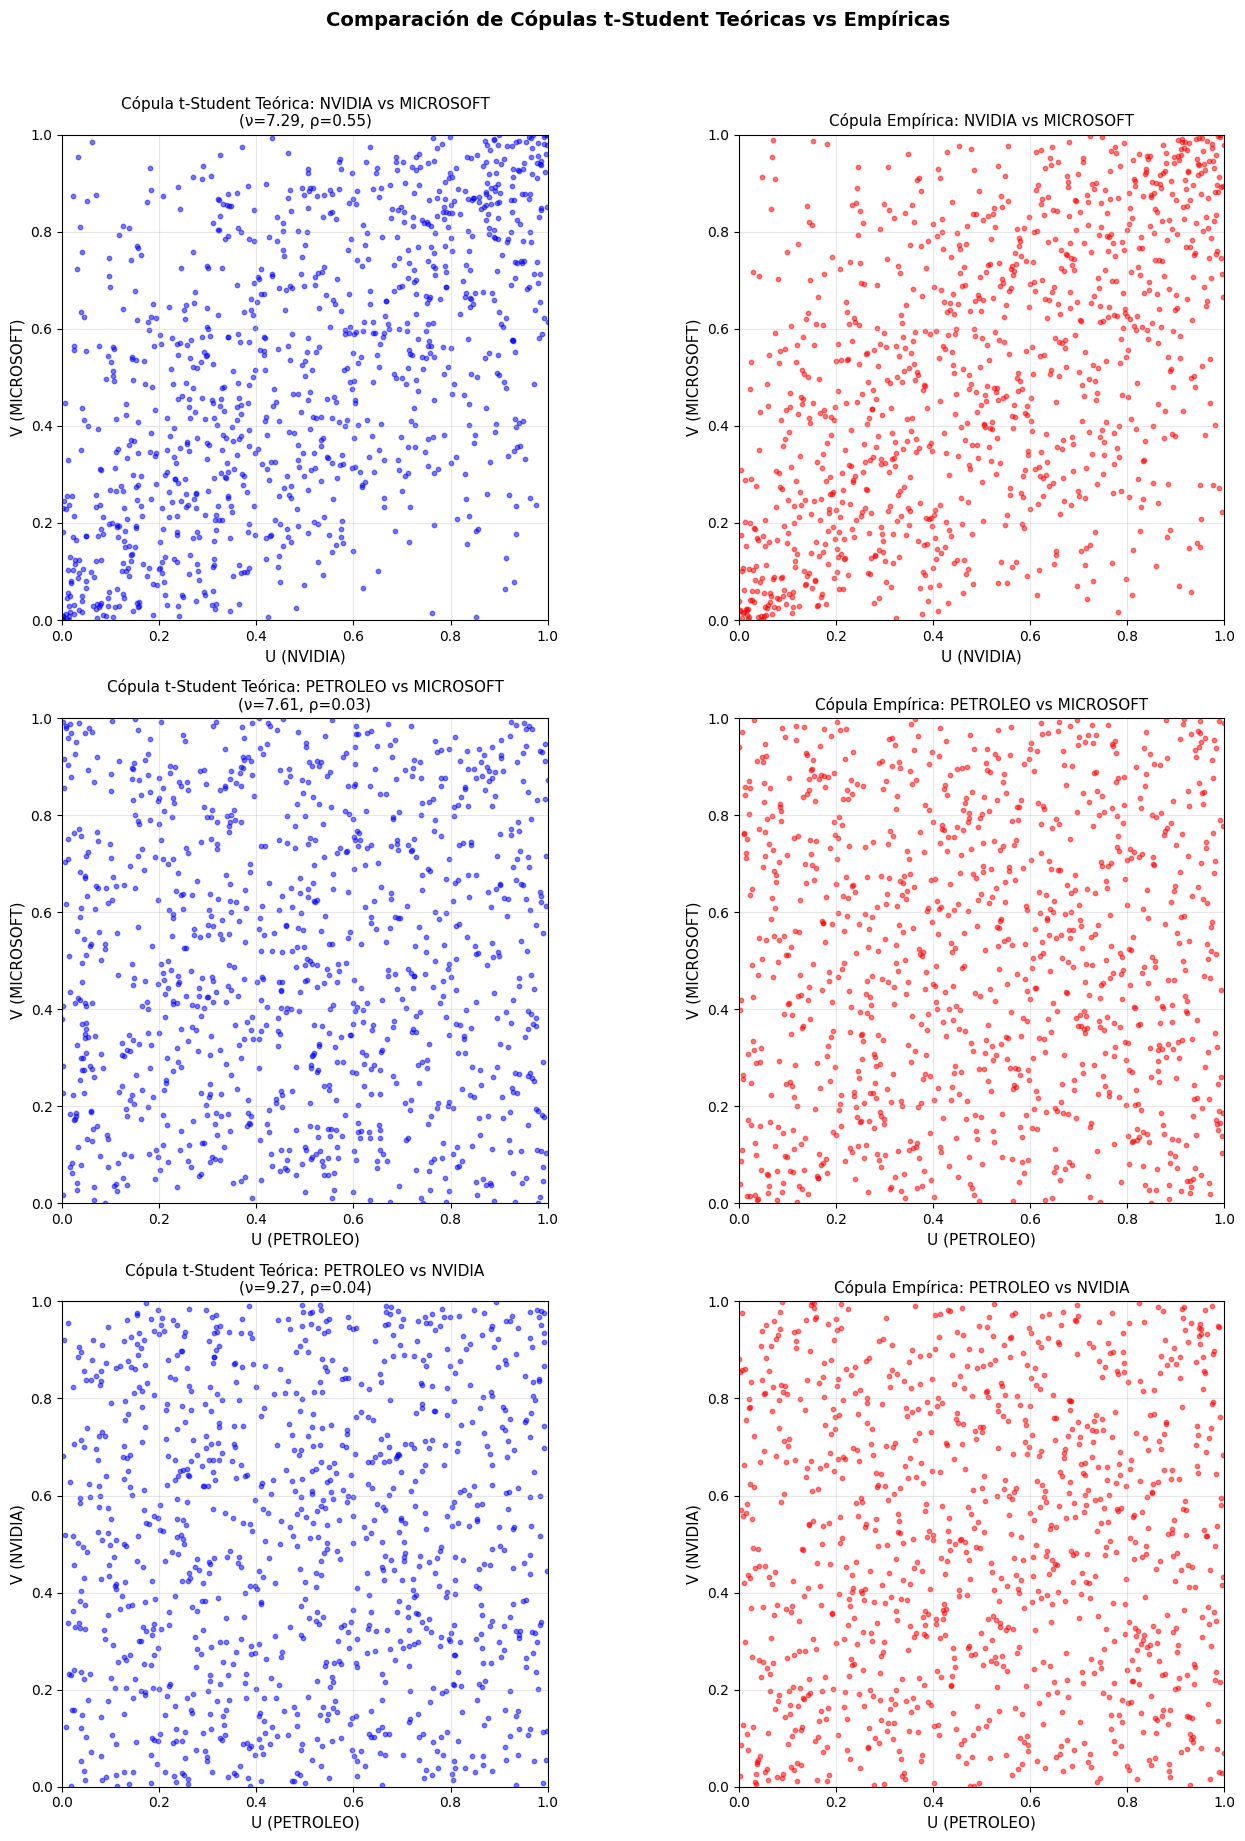

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

# ========== PAR 1: NVIDIA vs MICROSOFT ==========
axes[0, 0].scatter(u1_teorico, v1_teorico, alpha=0.5, c='blue', s=10)
axes[0, 0].set_xlabel('U (NVIDIA)', fontsize=11)
axes[0, 0].set_ylabel('V (MICROSOFT)', fontsize=11)
axes[0, 0].set_title(f'Cópula t-Student Teórica: NVIDIA vs MICROSOFT\n(ν={nu_NV_MIC:.2f}, ρ={rho_NV_MIC:.2f})', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim(0, 1)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_aspect('equal')

# Corrected empirical plot for NVIDIA vs Microsoft
axes[0, 1].scatter(v_nvd_mic, u_mic_nvd, alpha=0.5, c='red', s=10)
axes[0, 1].set_xlabel('U (NVIDIA)', fontsize=11)
axes[0, 1].set_ylabel('V (MICROSOFT)', fontsize=11)
axes[0, 1].set_title('Cópula Empírica: NVIDIA vs MICROSOFT', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, 1)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_aspect('equal')

# ========== PAR 2: PETROLEO vs MICROSOFT ==========
axes[1, 0].scatter(u2_teorico, v2_teorico, alpha=0.5, c='blue', s=10)
axes[1, 0].set_xlabel('U (PETROLEO)', fontsize=11)
axes[1, 0].set_ylabel('V (MICROSOFT)', fontsize=11)
axes[1, 0].set_title(f'Cópula t-Student Teórica: PETROLEO vs MICROSOFT\n(ν={nu_PET_MIC:.2f}, ρ={rho_PET_MIC:.2f})', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_aspect('equal')

# Corrected empirical plot for PETROLEO vs Microsoft
axes[1, 1].scatter(u_pet_mic, v_mic_pet, alpha=0.5, c='red', s=10)
axes[1, 1].set_xlabel('U (PETROLEO)', fontsize=11)
axes[1, 1].set_ylabel('V (MICROSOFT)', fontsize=11)
axes[1, 1].set_title('Cópula Empírica: PETROLEO vs MICROSOFT', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_aspect('equal')

# ========== PAR 3: PETROLEO vs NVIDIA ==========
axes[2, 0].scatter(u3_teorico, v3_teorico, alpha=0.5, c='blue', s=10)
axes[2, 0].set_xlabel('U (PETROLEO)', fontsize=11)
axes[2, 0].set_ylabel('V (NVIDIA)', fontsize=11)
axes[2, 0].set_title(f'Cópula t-Student Teórica: PETROLEO vs NVIDIA\n(ν={nu_PET_NVD:.2f}, ρ={rho_PET_NVD:.2f})', fontsize=11)
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].set_xlim(0, 1)
axes[2, 0].set_ylim(0, 1)
axes[2, 0].set_aspect('equal')

# Corrected empirical plot for PETROLEO vs NVIDIA
axes[2, 1].scatter(u_pet_nvd, v_nvd_pet, alpha=0.5, c='red', s=10)
axes[2, 1].set_xlabel('U (PETROLEO)', fontsize=11)
axes[2, 1].set_ylabel('V (NVIDIA)', fontsize=11)
axes[2, 1].set_title('Cópula Empírica: PETROLEO vs NVIDIA', fontsize=11)
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].set_xlim(0, 1)
axes[2, 1].set_ylim(0, 1)
axes[2, 1].set_aspect('equal')

plt.suptitle('Comparación de Cópulas t-Student Teóricas vs Empíricas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Reconstrucción de la serie de tiempo


In [ ]:
df_parametros_microsoft

,parametro,valor,error_std,p_valor
0,ar.L1,-0.531717,0.338833,1.165880e-01
1,ar.L2,-0.265132,0.330175,4.219715e-01
2,ar.L3,-0.375010,0.333442,2.607314e-01
3,ma.L1,0.521916,0.347550,1.331748e-01
4,ma.L2,0.211828,0.343432,5.373695e-01
5,ma.L3,0.296258,0.346839,3.930127e-01
6,ar.S.L100,0.000442,0.046593,9.924236e-01
7,ma.S.L100,-0.945011,0.209232,6.285031e-06
8,sigma2,0.000287,0.000052,3.062791e-08


In [ ]:
df_parametros_nvidia

,parametro,valor,error_std,p_valor
0,ar.L1,0.511757,2.353651,0.827872
1,ma.L1,-0.542250,2.353254,0.817761
2,ma.L2,0.007186,0.091535,0.937429
3,ar.S.L80,-0.836270,0.373898,0.025311
4,ma.S.L80,-0.170307,0.433834,0.694643
5,ma.S.L160,-0.793379,0.504292,0.115660
6,sigma2,0.001080,0.000296,0.000258


In [ ]:
df_parametros_petroleo

,parametro,valor,error_std,p_valor
0,ar.L1,0.028522,0.032266,3.767248e-01
1,ar.L2,-0.053912,0.026898,4.503588e-02
2,ar.S.L100,-0.644325,0.028811,8.913103e-111
3,ar.S.L200,-0.312178,0.031304,2.010554e-23
4,sigma2,0.000699,0.000024,1.380068e-188


In [ ]:
n_sim = 1000 #numero de simulaciones
nu_reconstruccion_mic_nvd = tabla_resultados3.loc[4, 'Parámetro 2']
rho_reconstruccion_mic_nvd = tabla_resultados3.loc[4, 'Parámetro 1']

nu_reconstruccion_pet_mic = tabla_resultados1.loc[4, 'Parámetro 2']
rho_reconstruccion_pet_mic = tabla_resultados1.loc[4, 'Parámetro 1']


In [ ]:
entr_micr.dropna(inplace=True)
entr_nvd.dropna(inplace=True)
entr_pet.dropna(inplace=True)

Microsoft

In [ ]:

#Coeficientes del modelo Microsoft
#    Modelo: (3,0,3)(1,1,1,100)
phi1   = df_parametros_microsoft.loc[0, 'valor']   # -0.531717
phi2   = df_parametros_microsoft.loc[1, 'valor']   # -0.265132
phi3   = df_parametros_microsoft.loc[2, 'valor']   # -0.375010
theta1 = df_parametros_microsoft.loc[3, 'valor']   #  0.521916
theta2 = df_parametros_microsoft.loc[4, 'valor']   #  0.211828
theta3 = df_parametros_microsoft.loc[5, 'valor']   #  0.296258
Phi1   = df_parametros_microsoft.loc[6, 'valor']   #  0.000442
Theta1 = df_parametros_microsoft.loc[7, 'valor']   # -0.945011
sigma2 = df_parametros_microsoft.loc[8, 'valor']   #  0.000287

# 2. Escala de los datos
escala_microsoft = np.sqrt(sigma2)

#3. Datos
entr_micr_clean = (entr_micr.dropna().values.flatten()
                   if hasattr(entr_micr, 'dropna')
                   else entr_micr[~np.isnan(entr_micr)])

n_micr  = len(entr_micr_clean)
max_lag = 203
valores_iniciales_y   = entr_micr_clean[:max_lag]
valores_iniciales_eps = resid_micr['residuos_m'].values[:max_lag]

# 4. Función para simular
#
#    (1 - phi1*B - phi2*B^2 - phi3*B^3)(1 - Phi1*B^100)(1 - B^100) x_t
#        = (1 + theta1*B + theta2*B^2 + theta3*B^3)(1 + Theta1*B^100) eps_t
#
#    Despejando x_t:
#
#    x_t = x_{t-100}
#          + phi1  * (x_{t-1}   - x_{t-101})
#          + phi2  * (x_{t-2}   - y_{t-102})
#          + phi3  * (x_{t-3}   - x_{t-103})
#          + Phi1  * (x_{t-100} - x_{t-200})
#          - phi1*Phi1 * (x_{t-101} - x_{t-201})
#          - phi2*Phi1 * (x_{t-102} - x_{t-202})
#          - phi3*Phi1 * (x_{t-103} - x_{t-203})
#          - theta1 * w_{t-1}
#          - theta2 * w_{t-2}
#          - theta3 * w_{t-3}
#          - Theta1 * w_{t-100}
#          - theta1*Theta1 * w_{t-101}
#          - theta2*Theta1 * w_{t-102}
#          - theta3*Theta1 * w_{t-103}
#          + w_t
def simular_sarima_microsoft(residuos_sinteticos,
                              phi1, phi2, phi3, Phi1,
                              theta1, theta2, theta3, Theta1,
                              y_init, eps_init,
                              max_lag=203):

    n = len(residuos_sinteticos)

    y   = np.zeros(n + max_lag)
    eps = np.zeros(n + max_lag)

    y[:max_lag]   = (y_init[:max_lag] if len(y_init) >= max_lag
                     else np.pad(y_init, (0, max_lag - len(y_init))))
    eps[:max_lag] = (eps_init[:max_lag] if len(eps_init) >= max_lag
                     else np.pad(eps_init, (0, max_lag - len(eps_init))))

    for t in range(max_lag, n + max_lag):
        e = residuos_sinteticos[t - max_lag]

        y[t] = (y[t-100]
                + phi1 * (y[t-1]   - y[t-101])
                + phi2 * (y[t-2]   - y[t-102])
                + phi3 * (y[t-3]   - y[t-103])
                + Phi1 * (y[t-100] - y[t-200])
                - phi1 * Phi1 * (y[t-101] - y[t-201])
                - phi2 * Phi1 * (y[t-102] - y[t-202])
                - phi3 * Phi1 * (y[t-103] - y[t-203])
                - theta1 * eps[t-1]
                - theta2 * eps[t-2]
                - theta3 * eps[t-3]
                - Theta1 * eps[t-100]
                - theta1 * Theta1 * eps[t-101]
                - theta2 * Theta1 * eps[t-102]
                - theta3 * Theta1 * eps[t-103]
                + e)

        eps[t] = e

    return y[max_lag:]

# 5. Simulaciones
simulaciones_microsoft = []

for _ in range(n_sim):
    u_mic_sim, _ = generar_copula_t(nu_reconstruccion_mic_nvd,rho_reconstruccion_mic_nvd,n_micr)
    residuos_sinteticos = escala_microsoft * stats.t.ppf(u_mic_sim,df=nu_reconstruccion_mic_nvd)
    y_sim = simular_sarima_microsoft(
        residuos_sinteticos,
        phi1, phi2, phi3, Phi1,
        theta1, theta2, theta3, Theta1,
        valores_iniciales_y,
        valores_iniciales_eps
    )

    simulaciones_microsoft.append(y_sim)

promedio_microsoft = np.mean(simulaciones_microsoft, axis=0)


# 6. Resultado
fechas_microsoft = pd.date_range(start='2020-09-28',periods=len(promedio_microsoft), freq='D')
serie_mic_reconstruida = pd.Series(promedio_microsoft,index=fechas_microsoft,name='Microsoft_Reconstruida')

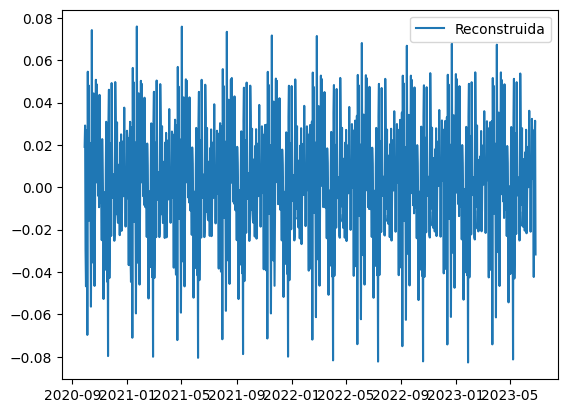

In [ ]:
plt.plot(serie_mic_reconstruida, label='Reconstruida')
plt.legend()
plt.show()

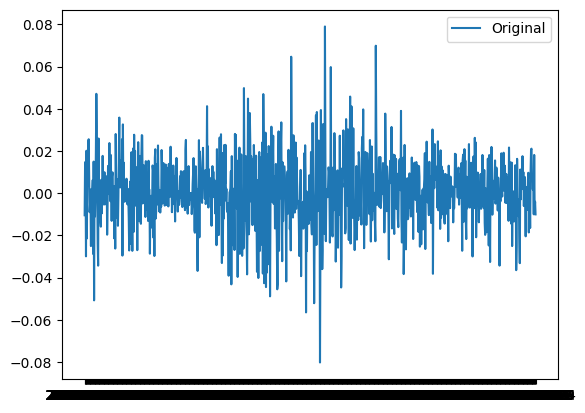

In [ ]:
plt.plot(entr_micr, label='Original')
plt.legend()
plt.show()

NVIDIA

In [ ]:
# 1. Coeficientes del modelo
#    Modelo: (1,0,2)(1,1,2,80)
phi1   =  0.511757
Phi1   = -0.836270
theta1 = -0.542250
theta2 =  0.007186
Theta1 = -0.170307
Theta2 = -0.793379
sigma2 =  0.001080

#2. Escala
escala_final = np.sqrt(sigma2)

#3. Datos
entr_nvd_clean = entr_nvd.dropna().values

n_nvidia = len(entr_nvd_clean)
max_lag  = 161

valores_iniciales_y   = entr_nvd_clean[:max_lag]
valores_iniciales_eps = resid_nvd['residuos_n'].values[:max_lag]

#4. Funcón de simulación
#    (1 - phi1*B)(1 - Phi1*B^80)(1 - B^80) y_t
#        = (1 - theta1*B - theta2*B^2)(1 - Theta1*B^80 - Theta2*B^160) eps_t
#
#    Despejando y_t:
#    y_t = y_{t-80}
#          + phi1  * (y_{t-1}   - y_{t-81})
#          + Phi1  * (y_{t-80}  - y_{t-160})
#          - phi1*Phi1 * (y_{t-81} - y_{t-161})
#          - theta1 * eps_{t-1}
#          - theta2 * eps_{t-2}
#          - Theta1 * eps_{t-80}
#          - Theta2 * eps_{t-160}
#          + eps_t

def simular_sarima(residuos_sinteticos,
                   phi1, Phi1,
                   theta1, theta2, Theta1, Theta2,
                   y_init, eps_init,
                   max_lag=161):

    n = len(residuos_sinteticos)

    y   = np.zeros(n + max_lag)
    eps = np.zeros(n + max_lag)

    # Se anexa para calcular el mismo tamaño que las otras simulaciones
    y[:max_lag]   = y_init[:max_lag]
    eps[:max_lag] = eps_init[:max_lag]

    for t in range(max_lag, n + max_lag):
        e = residuos_sinteticos[t - max_lag]

        y[t] = (y[t-80]
                + phi1 * (y[t-1]  - y[t-81])
                + Phi1 * (y[t-80] - y[t-160])
                - phi1 * Phi1 * (y[t-81] - y[t-161])
                - theta1 * eps[t-1]
                - theta2 * eps[t-2]
                - Theta1 * eps[t-80]
                - Theta2 * eps[t-160]
                + e)

        eps[t] = e

    return y[max_lag:]

#5. Simulación
simulaciones_y = []

for i in range(n_sim):
    _, v_nvd_sim = generar_copula_t(nu_reconstruccion_mic_nvd,rho_reconstruccion_mic_nvd,n_nvidia)
    residuos_sinteticos = escala_final * stats.t.ppf(v_nvd_sim,df=nu_reconstruccion_mic_nvd)
    y_sim = simular_sarima(residuos_sinteticos,
        phi1, Phi1,
        theta1, theta2, Theta1, Theta2,
        valores_iniciales_y,
        valores_iniciales_eps
    )

    simulaciones_y.append(y_sim)

serie_final = np.mean(simulaciones_y, axis=0)

#6. Resultado
fechas_nvidia = pd.date_range(start='2020-09-28',periods=len(serie_final), freq='D')
serie_nvd_reconstruida = pd.Series(serie_final,index=fechas_nvidia,name='NVIDIA_Reconstruida')


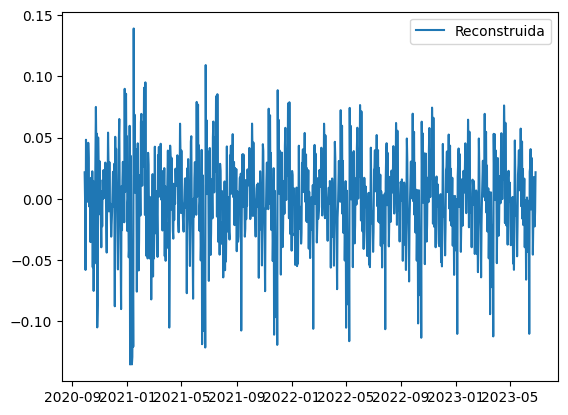

In [ ]:
plt.plot(serie_nvd_reconstruida, label='Reconstruida')
plt.legend()
plt.show()

In [ ]:
#1. Coeficientes del modelo
#    Modelo: (2,0,0)(2,1,0,100)

phi1_pet   = df_parametros_petroleo.loc[0, 'valor']   #  0.028522
phi2_pet   = df_parametros_petroleo.loc[1, 'valor']   # -0.053912
Phi1_pet   = df_parametros_petroleo.loc[2, 'valor']   # -0.644325
Phi2_pet   = df_parametros_petroleo.loc[3, 'valor']   # -0.312178
sigma2_pet = df_parametros_petroleo.loc[4, 'valor']   #  0.000699

#2. Escala
escala_petroleo = np.sqrt(sigma2_pet)

#3. Datos
entr_pet_clean = entr_pet.dropna().values.flatten()


n_pet   = len(entr_pet_clean)
max_lag = 302

valores_iniciales_y_pet = entr_pet_clean[:max_lag]
valores_iniciales_eps_pet = resid_pet['residuos_p'].values[:max_lag]

#4. Función de simulación
#    Modelo: (2,0,0)(2,1,0,100)
#
#    x_t = x_{t-100}
#          + phi1  * (x_{t-1}   - x_{t-101})
#          + phi2  * (x_{t-2}   - x_{t-102})
#          + Phi1  * (x_{t-100} - x_{t-200})
#          + Phi2  * (x_{t-200} - x_{t-300})
#          - phi1*Phi1 * (x_{t-101} - x_{t-201})
#          - phi1*Phi2 * (x_{t-201} - x_{t-301})
#          - phi2*Phi1 * (x_{t-102} - x_{t-202})
#          - phi2*Phi2 * (x_{t-202} - x_{t-302})
#          + w_t

def simular_ar_petroleo(residuos_sinteticos,
                         phi1, phi2, Phi1, Phi2,
                         y_init,
                         max_lag=302):

    n = len(residuos_sinteticos)

    y = np.zeros(n + max_lag)

    y[:max_lag] = (y_init[:max_lag] if len(y_init) >= max_lag
                   else np.pad(y_init, (0, max_lag - len(y_init))))

    for t in range(max_lag, n + max_lag):
        e = residuos_sinteticos[t - max_lag]

        y[t] = (y[t-100]
                + phi1 * (y[t-1]   - y[t-101])
                + phi2 * (y[t-2]   - y[t-102])
                + Phi1 * (y[t-100] - y[t-200])
                + Phi2 * (y[t-200] - y[t-300])
                - phi1 * Phi1 * (y[t-101] - y[t-201])
                - phi1 * Phi2 * (y[t-201] - y[t-301])
                - phi2 * Phi1 * (y[t-102] - y[t-202])
                - phi2 * Phi2 * (y[t-202] - y[t-302])
                + e)

    return y[max_lag:]

#5. Simulación
simulaciones_petroleo = []

for _ in range(n_sim):
    u_pet_sim, _ = generar_copula_t(nu_reconstruccion_pet_mic,rho_reconstruccion_pet_mic,n_pet)
    residuos_sinteticos = escala_petroleo * stats.t.ppf(u_pet_sim,df=nu_reconstruccion_pet_mic)
    y_sim = simular_ar_petroleo(
        residuos_sinteticos,
        phi1_pet, phi2_pet, Phi1_pet, Phi2_pet,
        valores_iniciales_y_pet
    )

    simulaciones_petroleo.append(y_sim)

promedio_petroleo = np.mean(simulaciones_petroleo, axis=0)

#6. Resultados


fechas_petroleo = pd.date_range(start='2020-09-28',periods=len(promedio_petroleo), freq='D')
serie_petroleo_reconstruida = pd.Series(promedio_petroleo,
                                         index=fechas_petroleo,
                                         name='Petroleo_Reconstruida')

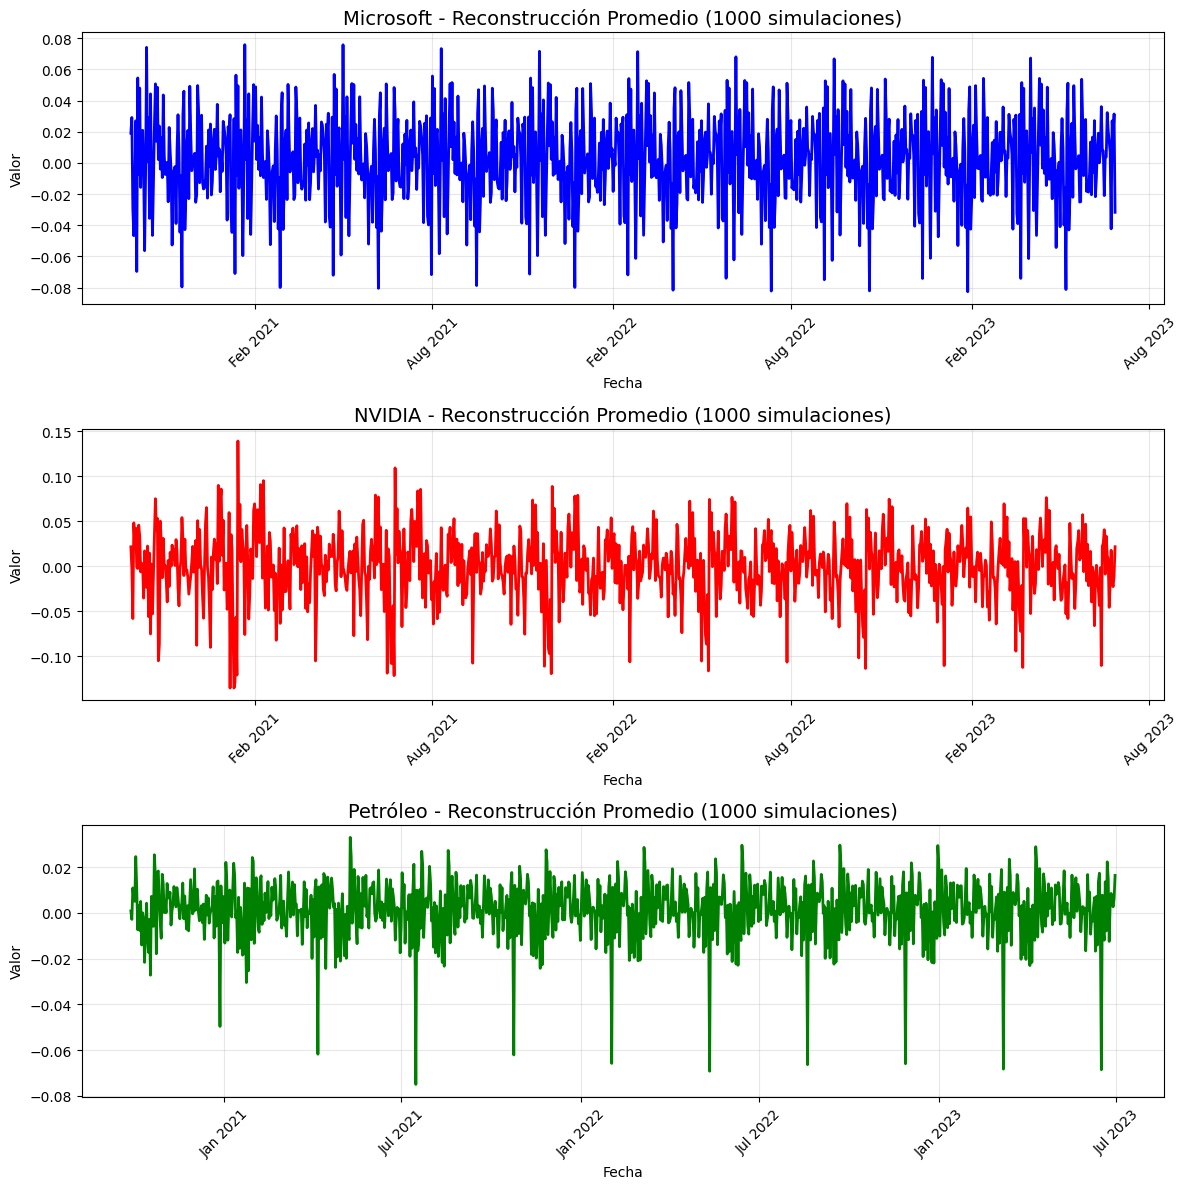

In [ ]:
import matplotlib.dates as mdates
serie_mic_reconstruida.index = pd.to_datetime(serie_mic_reconstruida.index)
serie_nvd_reconstruida.index = pd.to_datetime(serie_nvd_reconstruida.index)
serie_petroleo_reconstruida.index = pd.to_datetime(serie_petroleo_reconstruida.index)

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Microsoft
axes[0].plot(serie_mic_reconstruida.index, serie_mic_reconstruida.values, 'b-', linewidth=2)
axes[0].set_title(f'Microsoft - Reconstrucción Promedio ({n_sim} simulaciones)', fontsize=14)
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Valor')
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].tick_params(axis='x', rotation=45)

#NVIDIA
axes[1].plot(serie_nvd_reconstruida.index, serie_nvd_reconstruida.values, 'r-', linewidth=2)
axes[1].set_title(f'NVIDIA - Reconstrucción Promedio ({n_sim} simulaciones)', fontsize=14)
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Valor')
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].tick_params(axis='x', rotation=45)

# Petróleo
axes[2].plot(serie_petroleo_reconstruida.index, serie_petroleo_reconstruida.values, 'g-', linewidth=2)
axes[2].set_title(f'Petróleo - Reconstrucción Promedio ({n_sim} simulaciones)', fontsize=14)
axes[2].set_xlabel('Fecha')
axes[2].set_ylabel('Valor')
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
def calcular_es(rendimientos, u1, alpha=0.95):
    """
    Calcula el Expected Shortfall (ES) para un portafolio de dos activos

    Parámetros:
    rendimientos: DataFrame con rendimientos de los dos activos
    u1: porcentaje asignado al primer activo
    alpha: nivel de confianza para ES (por defecto 95%)

    Retorna:
    ES: Expected Shortfall
    """
    u2 = 1 - u1 #Solo se tomará el valor u1
    rend_portafolio = u1 * rendimientos.iloc[:, 0] + u2 * rendimientos.iloc[:, 1]# Calcular rendimiento del portafolio
    perdida = -rend_portafolio # Calcular pérdida (negativo del rendimiento)
    var = np.percentile(perdida, alpha * 100) # Calcular VaR (percentil alpha de las pérdidas)
    es = perdida[perdida >= var].mean() # Calcular ES (media de las pérdidas que superan el VaR)

    return es

In [ ]:
def optimizar_es_malla(rendimientos, alpha=0.95, n_puntos=100, df_name='Portafolio'):

    rendimientos_clean = rendimientos.dropna()
    nombre_activo1 = rendimientos_clean.columns[0]
    nombre_activo2 = rendimientos_clean.columns[1]

    malla_u1 = np.linspace(0, 1, n_puntos)
    resultados = []

    for u1 in malla_u1:
        es = calcular_es(rendimientos_clean, u1, alpha)
        u2 = 1 - u1
        rend_port = u1 * rendimientos_clean.iloc[:, 0] + u2 * rendimientos_clean.iloc[:, 1]
        rend_esperado = rend_port.mean() * 252
        volatilidad = rend_port.std() * np.sqrt(252)
        perdida = -rend_port
        var = np.percentile(perdida, alpha * 100)

        resultados.append({
            nombre_activo1: u1,
            nombre_activo2: u2,
            'ES': es,
            'VaR': var,
            'Rendimiento_Anual': rend_esperado,
            'Volatilidad_Anual': volatilidad,
        })

    resultados_df = pd.DataFrame(resultados)

    idx_optimo = resultados_df['ES'].idxmin()
    u1_optimo = resultados_df.loc[idx_optimo, nombre_activo1]
    es_minimo = resultados_df.loc[idx_optimo, 'ES']

    print(f'Resultados para {df_name}')
    print(f'El ES minimo es: {es_minimo:.4f}')
    print(f'Peso óptimo {nombre_activo1}: {u1_optimo:.4f}')
    print(f'Peso óptimo {nombre_activo2}: {1 - u1_optimo:.4f}')
    print(f'Rendimiento esperado del portafolio: {rend_esperado:.4f}')
    print(f'Rendimiento diario promedio: {rend_port.mean():.6f}')

    return resultados_df, u1_optimo, es_minimo

#### NVIDIA-MICROSOFT

In [ ]:
rendimientos_mc_nvda= pd.DataFrame({
    'Microsoft': serie_mic_reconstruida,
    'NVIDIA': serie_nvd_reconstruida})

rendimientos_pet_nvda= pd.DataFrame({
    'Petroleo': serie_petroleo_reconstruida,
    'NVIDIA': serie_nvd_reconstruida})

rendimientos_pet_mic= pd.DataFrame({
    'Petroleo': serie_petroleo_reconstruida,
    'Microsoft': serie_mic_reconstruida})

1. Grafica de rendimientos de cada uno de los resultados
2. Bonos (agrgegar otro activo) cetes, derivados

In [ ]:
resultados1,u1_optimo1, es_minimo1 = optimizar_es_malla(rendimientos_mc_nvda, df_name='NVIDIA-MICROSOFT')

Resultados para NVIDIA-MICROSOFT
El ES minimo es: 0.0462
Peso óptimo Microsoft: 0.6465
Peso óptimo NVIDIA: 0.3535
Rendimiento esperado del portafolio: 0.6620
Rendimiento diario promedio: 0.002627


In [ ]:
resultados2,u1_optimo2, es_minimo2 = optimizar_es_malla(rendimientos_pet_nvda, df_name='PETROLEO-NVIDIA')

Resultados para PETROLEO-NVIDIA
El ES minimo es: 0.0268
Peso óptimo Petroleo: 0.8283
Peso óptimo NVIDIA: 0.1717
Rendimiento esperado del portafolio: 0.3465
Rendimiento diario promedio: 0.001375


In [ ]:
resultados3,u1_optimo3, es_minimo3 = optimizar_es_malla(rendimientos_pet_mic, df_name='PETROLEO-MICROSOFT')

Resultados para PETROLEO-MICROSOFT
El ES minimo es: 0.0254
Peso óptimo Petroleo: 0.8081
Peso óptimo Microsoft: 0.1919
Rendimiento esperado del portafolio: 0.3465
Rendimiento diario promedio: 0.001375


In [ ]:
micr=pd.read_csv(os.path.join(base_path2, 'entrenamiento_microsoft.csv'))
nvd=pd.read_csv(os.path.join(base_path2, 'entrenamiento_nvidia.csv'))
pet=pd.read_csv(os.path.join(base_path2, 'entrenamiento_petroleo.csv'))

In [ ]:
primer_nvd=nvd['Close'][0]
primer_nvd_dia=nvd['Date'][0]
ultimo_nvd=nvd['Close'][len(nvd)-1]
ultimo_nvd_dia=nvd['Date'][len(nvd)-1]
print(f'Primer valor de NVIDIA: {primer_nvd} el {primer_nvd_dia}')
print(f'Último valor de NVIDIA: {ultimo_nvd} el {ultimo_nvd_dia}')


Primer valor de NVIDIA: 13.03499984741211 el 2020-09-28
Último valor de NVIDIA: 120.87000274658205 el 2024-09-24


In [ ]:
primer_micr=micr['Close'][0]
primer_micr_dia=micr['Date'][0]
ultimo_micr=micr['Close'][len(micr)-1]
ultimo_micr_dia=micr['Date'][len(micr)-1]
print(f'Primer valor de Microsoft: {primer_micr} el {primer_micr_dia}')
print(f'Último valor de Microsoft: {ultimo_micr} el {ultimo_micr_dia}')

Primer valor de Microsoft: 209.44000244140625 el 2020-09-28
Último valor de Microsoft: 429.1700134277344 el 2024-09-24


In [ ]:
primer_pet=pet['Close'][0]
primer_pet_dia=pet['Date'][0]
ultimo_pet=pet['Close'][len(pet)-1]
ultimo_pet_dia=pet['Date'][len(pet)-1]
print(f'Primer valor de Petroleo: {primer_pet} el {primer_pet_dia}')
print(f'Último valor de Petroleo: {ultimo_pet} el {ultimo_pet_dia}')

Primer valor de Petroleo: 42.43000030517578 el 2020-09-28
Último valor de Petroleo: 71.5999984741211 el 2024-09-26
